# **1. Perkenalan Dataset**

## Heart Disease Dataset

Dataset ini berasal dari **UCI Machine Learning Repository** dan tersedia di Kaggle:
- **Sumber**: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
- **Task**: Binary Classification (prediksi penyakit jantung)
- **Target**: `target` — 0 = tidak ada penyakit jantung, 1 = ada penyakit jantung

### Deskripsi Fitur:
| Fitur | Deskripsi |
|---|---|
| age | Usia pasien |
| sex | Jenis kelamin (1=pria, 0=wanita) |
| cp | Tipe nyeri dada (0-3) |
| trestbps | Tekanan darah saat istirahat (mm Hg) |
| chol | Kolesterol serum (mg/dl) |
| fbs | Gula darah puasa > 120 mg/dl (1=ya, 0=tidak) |
| restecg | Hasil EKG saat istirahat (0-2) |
| thalach | Detak jantung maksimum |
| exang | Angina akibat olahraga (1=ya, 0=tidak) |
| oldpeak | Depresi ST akibat olahraga |
| slope | Kemiringan segmen ST (0-2) |
| ca | Jumlah pembuluh darah besar (0-3) |
| thal | Thalassemia (0-3) |
| target | Diagnosis penyakit jantung (0=tidak, 1=ya) |

# **2. Import Library**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.2.3
NumPy version: 2.2.5


# **3. Memuat Dataset**

In [9]:
# Load dataset
df = pd.read_csv('heart.csv')

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'\n5 baris pertama:')
df.head()

Dataset berhasil dimuat!
Shape: (1025, 14)

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
# Informasi dasar dataset
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [11]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== STATISTIK DESKRIPTIF ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

## 4.1 Pengecekan Missing Values

In [12]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_pct
})

print('=== MISSING VALUES ===')
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== MISSING VALUES ===
          Missing Count  Missing Percentage (%)
age                   0                     0.0
sex                   0                     0.0
cp                    0                     0.0
trestbps              0                     0.0
chol                  0                     0.0
fbs                   0                     0.0
restecg               0                     0.0
thalach               0                     0.0
exang                 0                     0.0
oldpeak               0                     0.0
slope                 0                     0.0
ca                    0                     0.0
thal                  0                     0.0
target                0                     0.0

Total missing values: 0


## 4.2 Pengecekan Duplikasi

In [13]:
# Cek duplikasi
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
print(f'Persentase duplikat: {(duplicates/len(df))*100:.2f}%')

if duplicates > 0:
    print('\nContoh baris duplikat:')
    print(df[df.duplicated()])

Jumlah data duplikat: 723
Persentase duplikat: 70.54%

Contoh baris duplikat:
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4  

## 4.3 Distribusi Target

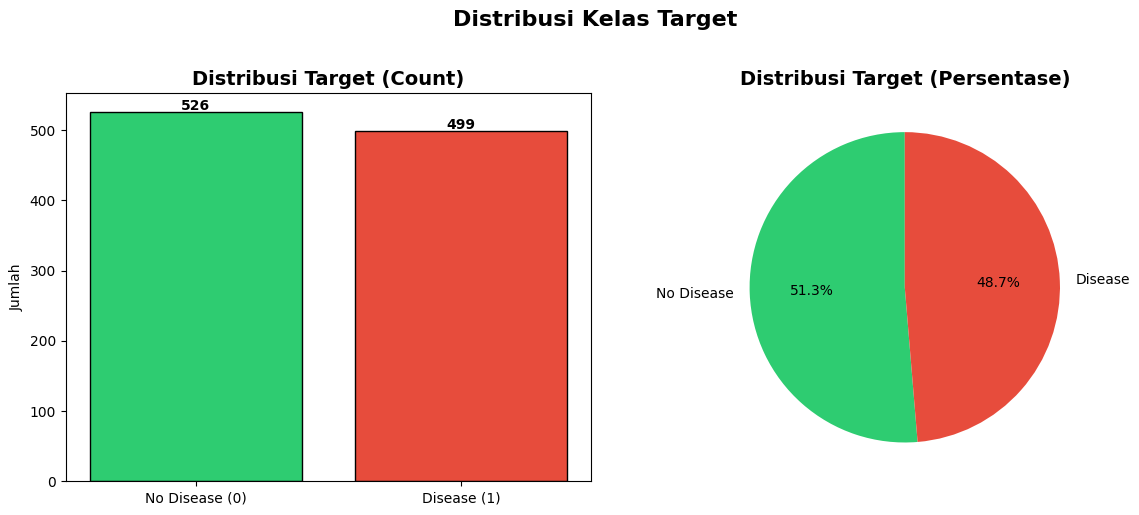


Distribusi target:
target
1    526
0    499
Name: count, dtype: int64

Rasio kelas: 0.95:1


In [14]:
# Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Target (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Disease'], 
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Target (Persentase)', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Kelas Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDistribusi target:')
print(target_counts)
print(f'\nRasio kelas: {target_counts[0]/target_counts[1]:.2f}:1')

## 4.4 Distribusi Fitur Numerik

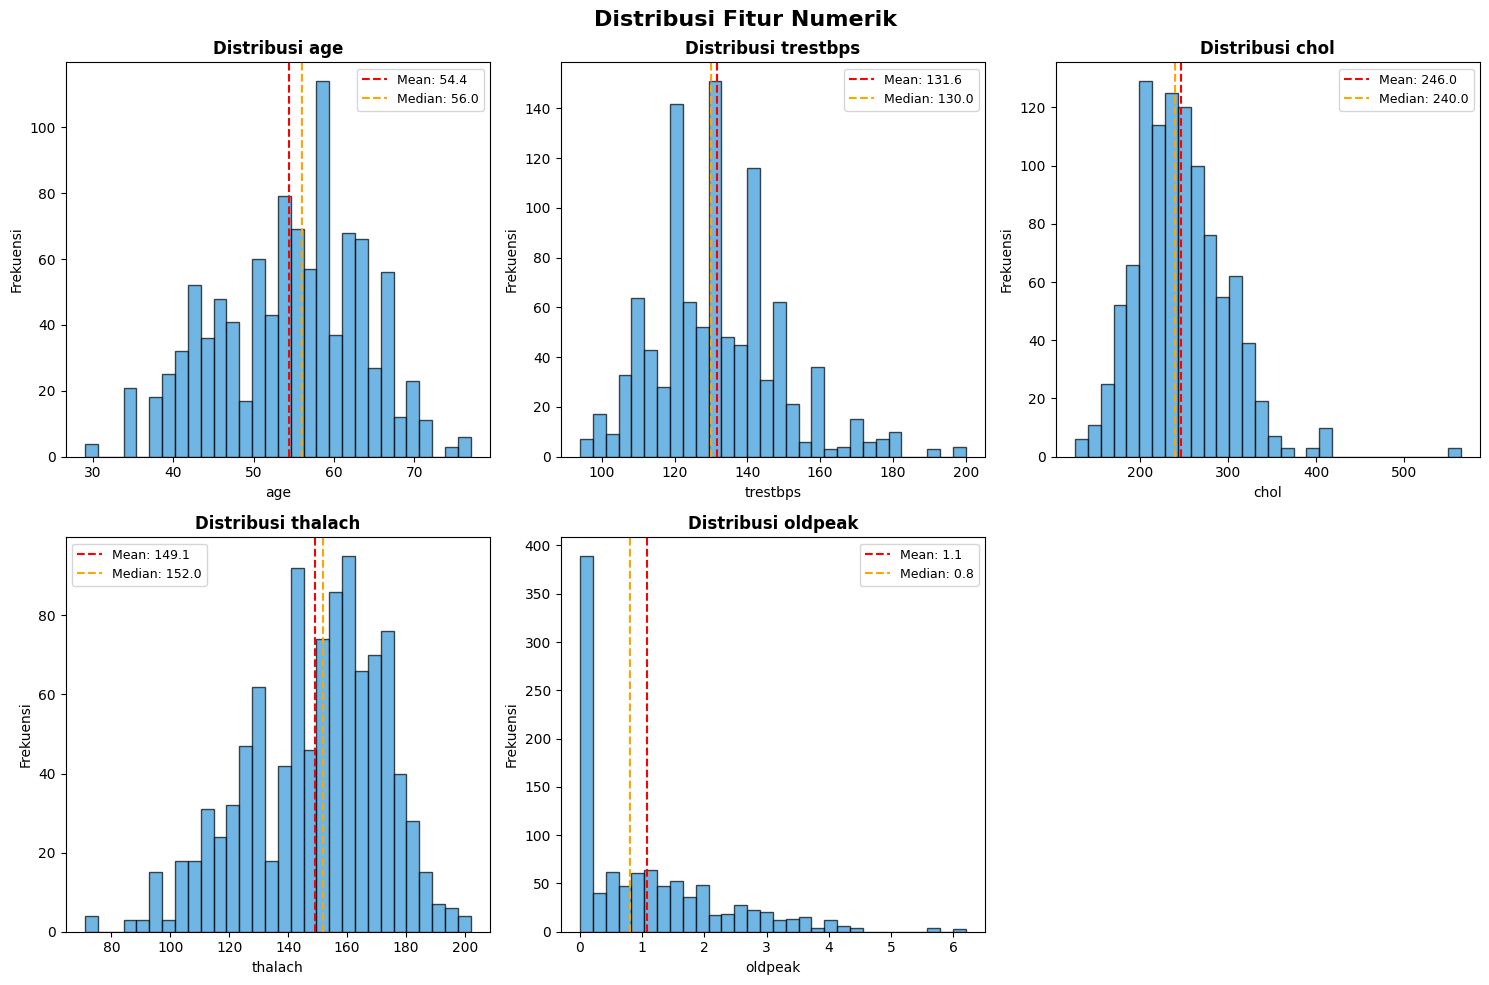

In [15]:
# Distribusi fitur numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=9)

axes[5].axis('off')
plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Distribusi Fitur Kategorikal

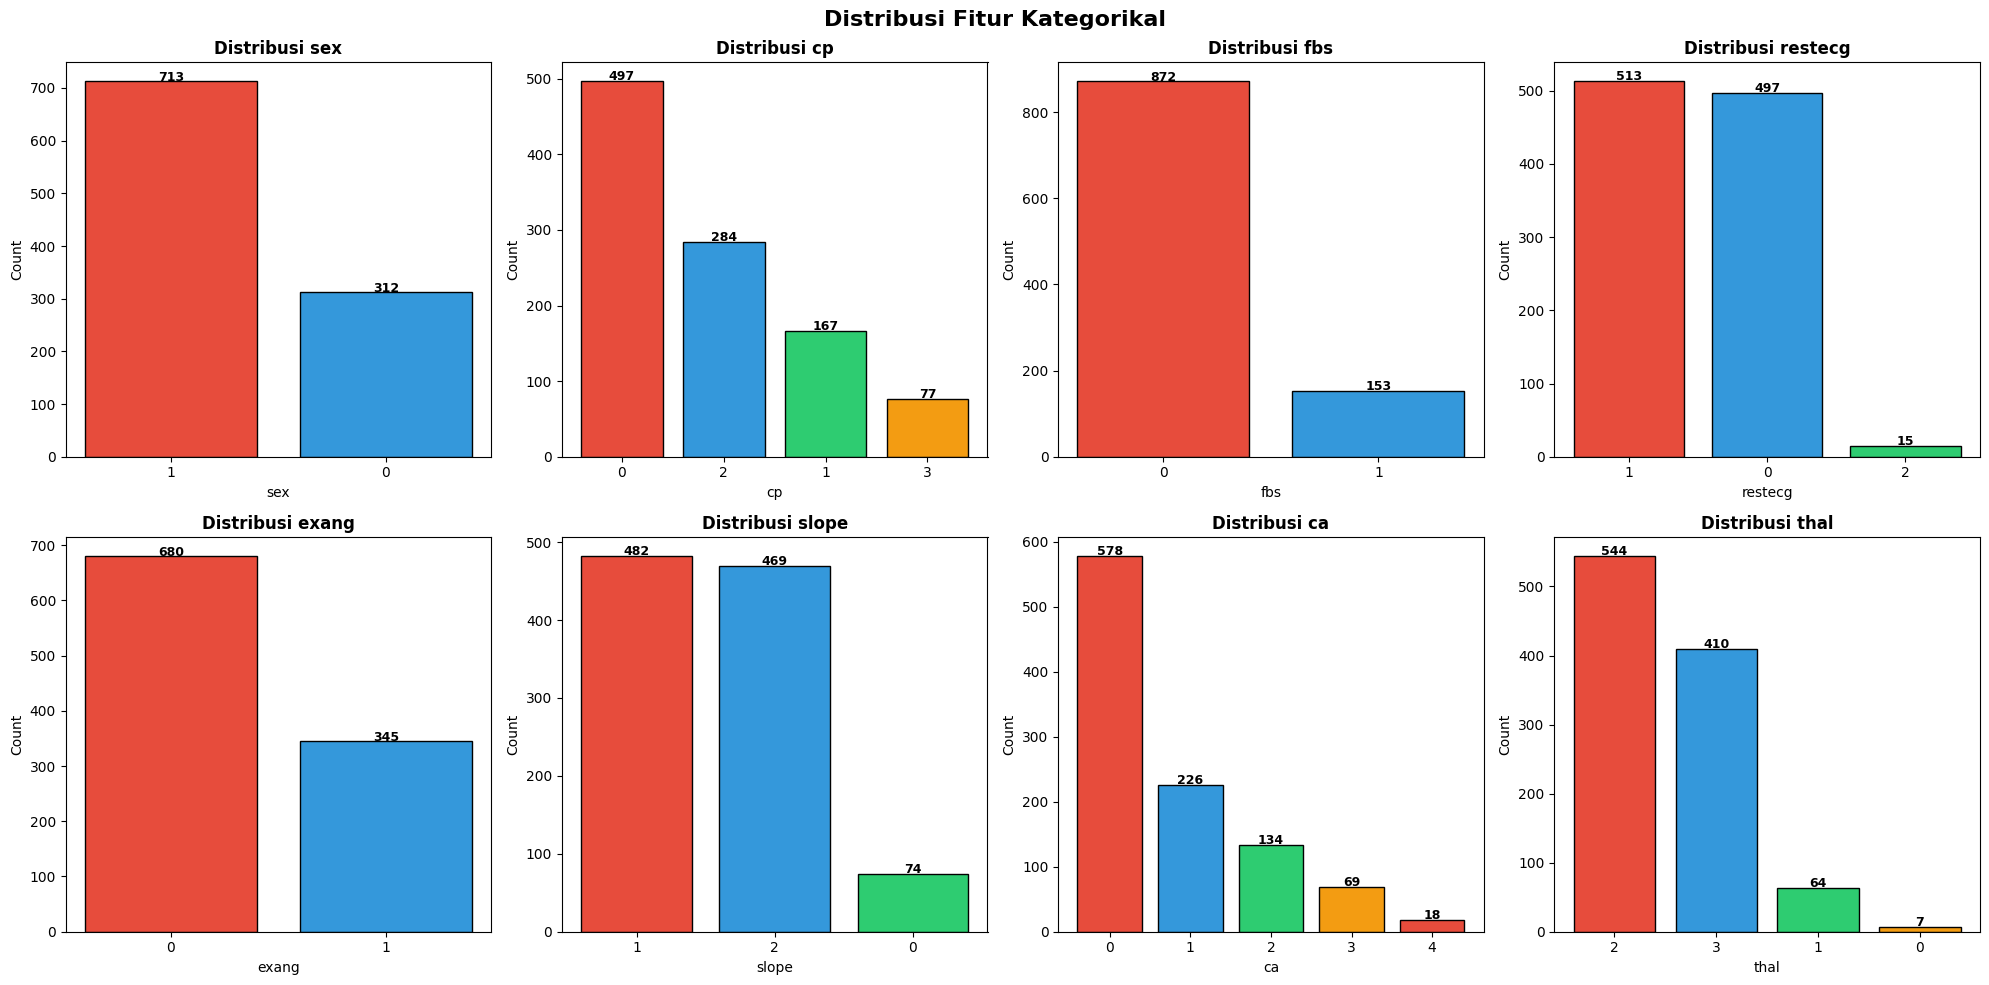

In [16]:
# Fitur kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, col in enumerate(categorical_cols):
    val_counts = df[col].value_counts()
    bar_colors = colors[:len(val_counts)]
    axes[i].bar(val_counts.index.astype(str), val_counts.values, 
                color=bar_colors, edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(val_counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Korelasi Antar Fitur

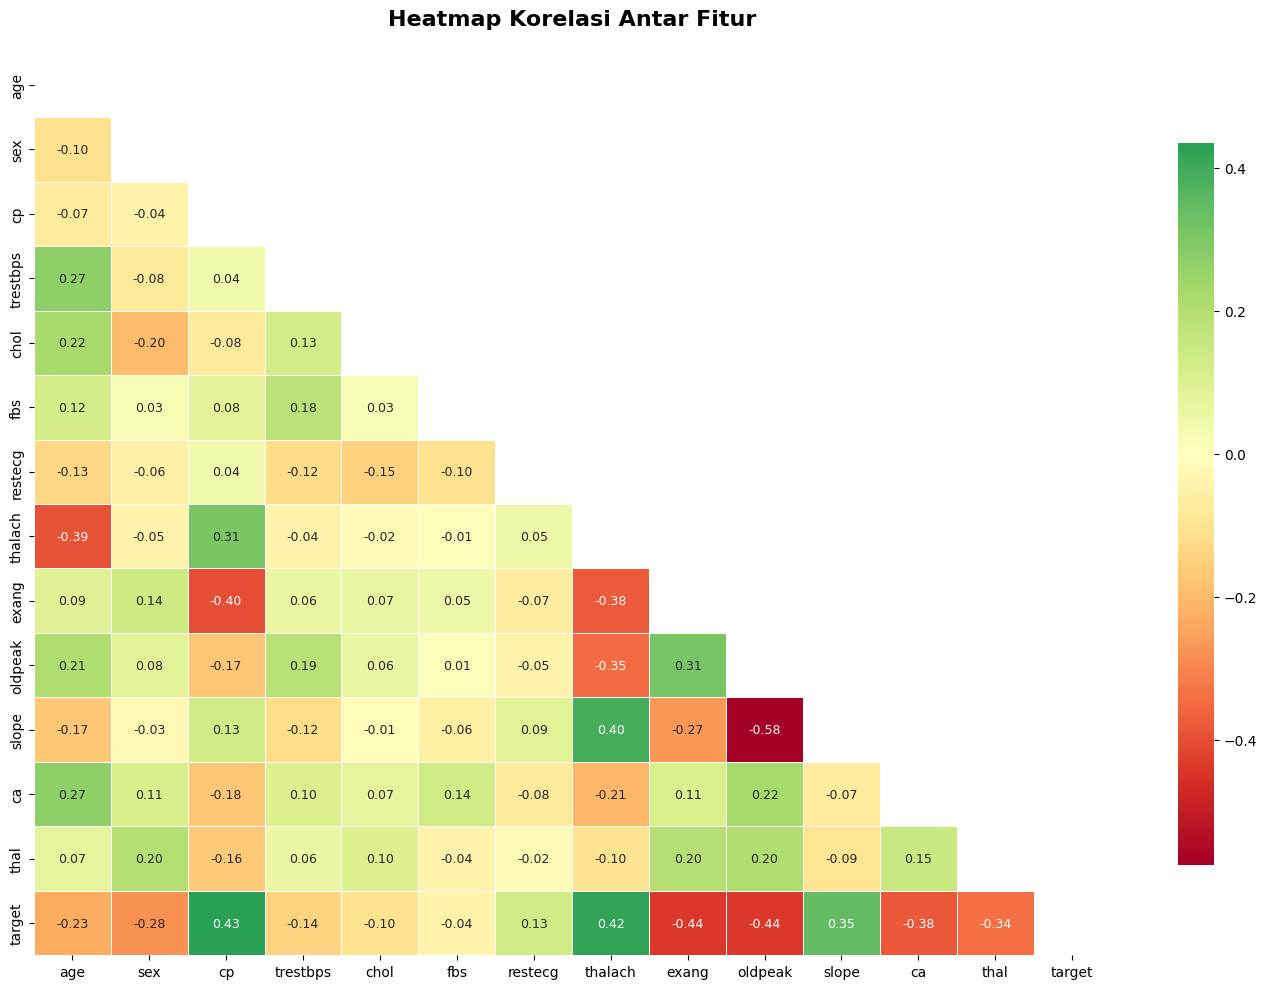

=== KORELASI DENGAN TARGET ===
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [17]:
# Heatmap korelasi
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})

plt.title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Korelasi dengan target
print('=== KORELASI DENGAN TARGET ===')
target_corr = df.corr()['target'].sort_values(ascending=False)
print(target_corr)

## 4.7 Deteksi Outlier (Boxplot)

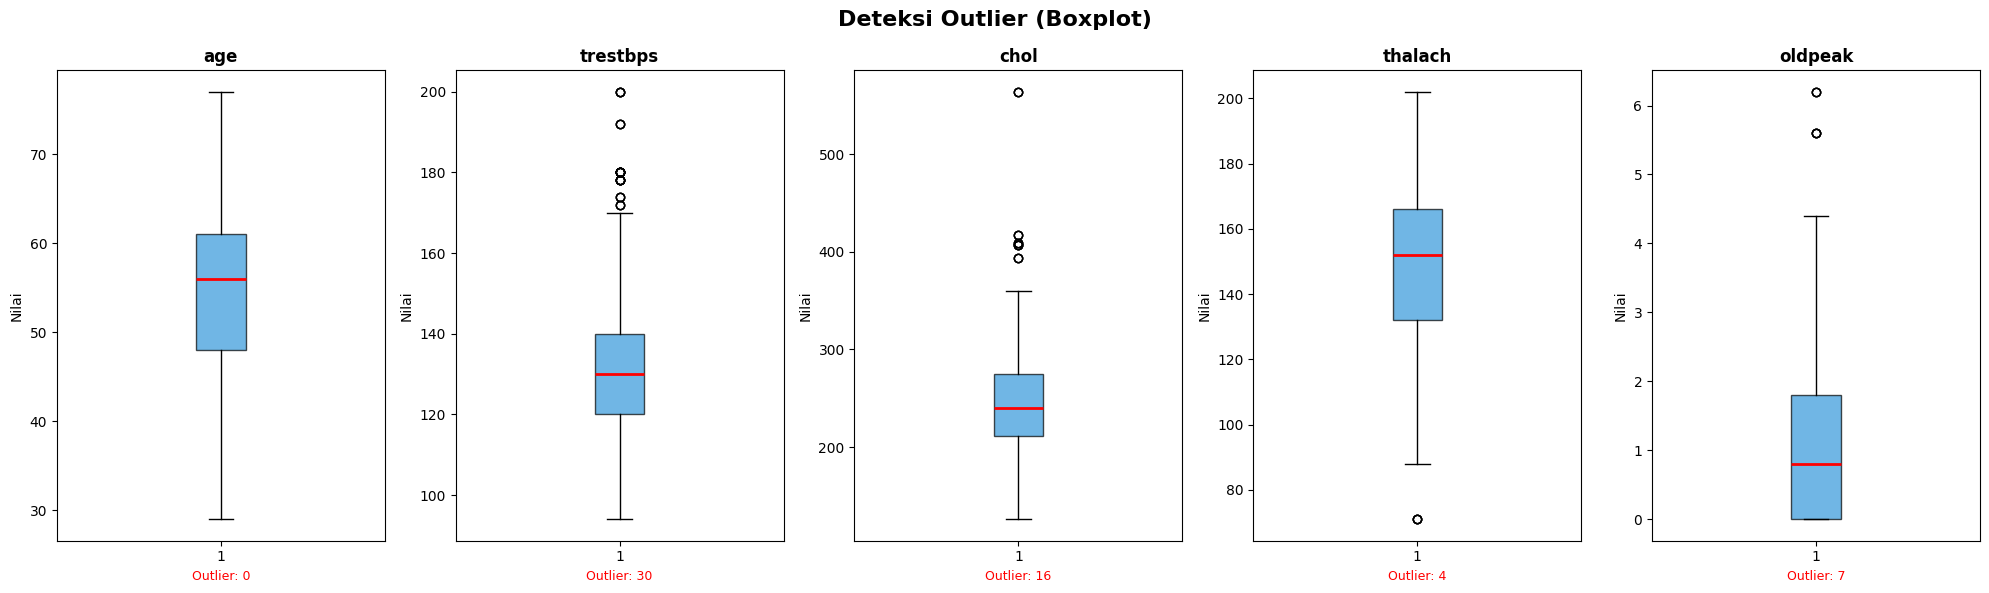

In [18]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai')
    
    # Hitung outlier dengan IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    axes[i].set_xlabel(f'Outlier: {len(outliers)}', fontsize=9, color='red')

plt.suptitle('Deteksi Outlier (Boxplot)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.8 Hubungan Fitur dengan Target

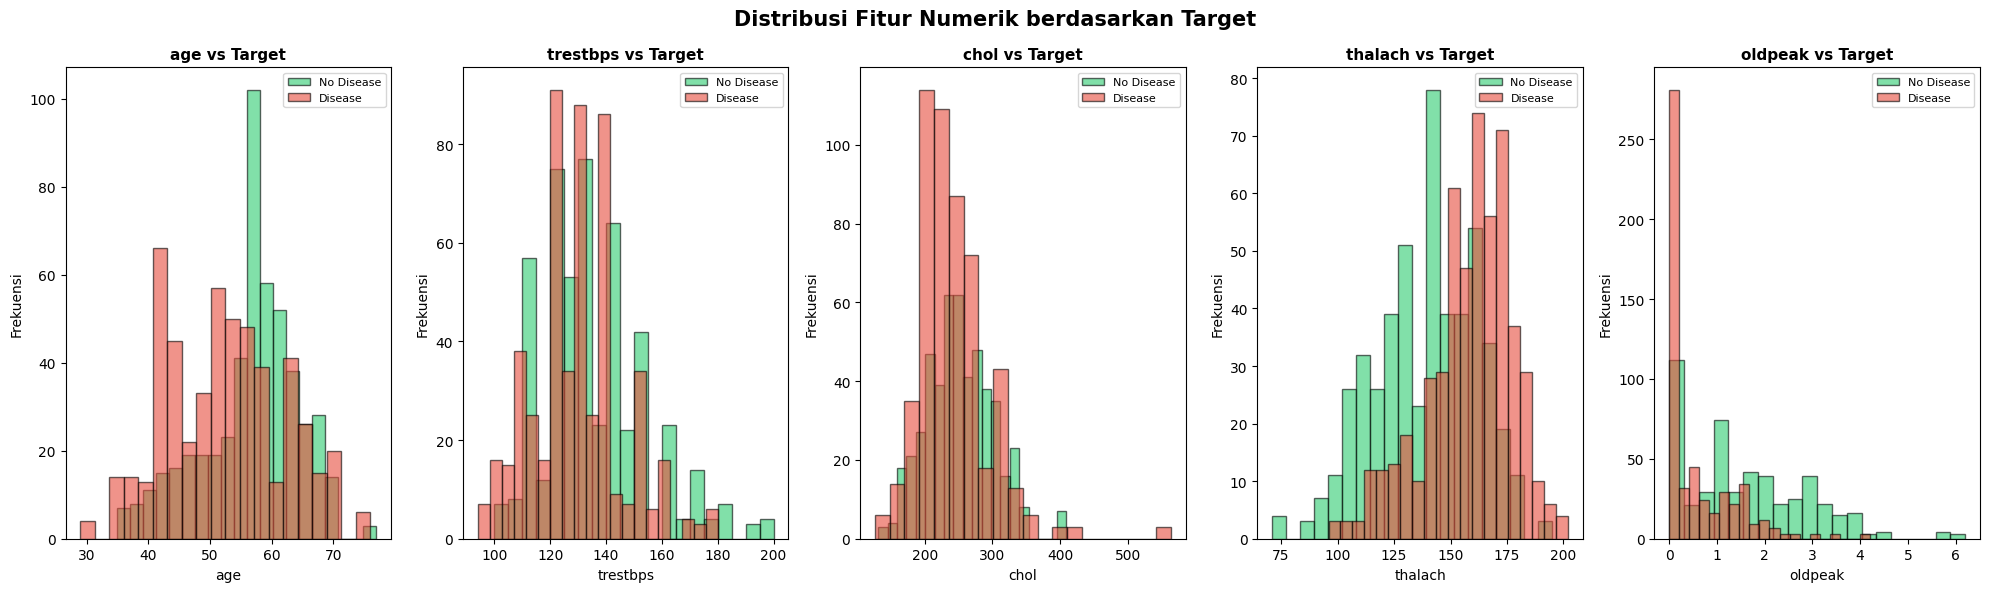

In [19]:
# Fitur numerik vs target
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, col in enumerate(numerical_cols):
    data_0 = df[df['target']==0][col]
    data_1 = df[df['target']==1][col]
    
    axes[i].hist(data_0, bins=20, alpha=0.6, label='No Disease', color='#2ecc71', edgecolor='black')
    axes[i].hist(data_1, bins=20, alpha=0.6, label='Disease', color='#e74c3c', edgecolor='black')
    axes[i].set_title(f'{col} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Target', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. Data Preprocessing**

## 5.1 Menghapus Data Duplikat

In [20]:
print(f'Shape sebelum drop duplikat: {df.shape}')
df_clean = df.drop_duplicates()
print(f'Shape setelah drop duplikat: {df_clean.shape}')
print(f'Baris yang dihapus: {len(df) - len(df_clean)}')

df_clean = df_clean.reset_index(drop=True)
print('\nData duplikat berhasil dihapus!')

Shape sebelum drop duplikat: (1025, 14)
Shape setelah drop duplikat: (302, 14)
Baris yang dihapus: 723

Data duplikat berhasil dihapus!


## 5.2 Menangani Missing Values

In [21]:
print(f'Missing values sebelum penanganan:')
print(df_clean.isnull().sum())

# Isi missing values numerik dengan median, kategorikal dengan modus
numerical_cols_all = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols_all = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in numerical_cols_all:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  {col}: diisi dengan median = {median_val}')

for col in categorical_cols_all:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  {col}: diisi dengan modus = {mode_val}')

print(f'\nMissing values setelah penanganan:')
print(df_clean.isnull().sum())

Missing values sebelum penanganan:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values setelah penanganan:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 5.3 Encoding Fitur Kategorikal

In [22]:
print('Shape sebelum encoding:', df_clean.shape)
print('\nFitur sebelum encoding:', list(df_clean.columns))

# One-Hot Encoding untuk fitur multi-kelas
multi_class_cols = ['cp', 'restecg', 'slope', 'thal']

df_encoded = pd.get_dummies(df_clean, columns=multi_class_cols, prefix=multi_class_cols, drop_first=False)

print('\nShape setelah encoding:', df_encoded.shape)
print('\nFitur setelah encoding:', list(df_encoded.columns))

Shape sebelum encoding: (302, 14)

Fitur sebelum encoding: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Shape setelah encoding: (302, 24)

Fitur setelah encoding: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_0', 'thal_1', 'thal_2', 'thal_3']


## 5.4 Deteksi dan Penanganan Outlier (IQR Method)

In [23]:
print('Shape sebelum penanganan outlier:', df_encoded.shape)

df_no_outlier = df_encoded.copy()

for col in numerical_cols_all:
    Q1 = df_no_outlier[col].quantile(0.25)
    Q3 = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count = ((df_no_outlier[col] < lower) | (df_no_outlier[col] > upper)).sum()
    
    # Clipping outlier ke batas IQR
    df_no_outlier[col] = df_no_outlier[col].clip(lower=lower, upper=upper)
    print(f'  {col}: {outlier_count} outlier di-clip ke [{lower:.2f}, {upper:.2f}]')

print('\nShape setelah penanganan outlier:', df_no_outlier.shape)

Shape sebelum penanganan outlier: (302, 24)
  age: 0 outlier di-clip ke [28.50, 80.50]
  trestbps: 9 outlier di-clip ke [90.00, 170.00]
  chol: 5 outlier di-clip ke [115.38, 370.38]
  thalach: 1 outlier di-clip ke [84.12, 215.12]
  oldpeak: 5 outlier di-clip ke [-2.40, 4.00]

Shape setelah penanganan outlier: (302, 24)


## 5.5 Normalisasi Fitur Numerik (StandardScaler)

In [24]:
# Pisahkan fitur dan target
X = df_no_outlier.drop('target', axis=1)
y = df_no_outlier['target']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nDistribusi target:')
print(y.value_counts())

# Normalisasi hanya untuk kolom numerik
scaler = StandardScaler()
X[numerical_cols_all] = scaler.fit_transform(X[numerical_cols_all])

print('\nStatistik setelah normalisasi:')
print(X[numerical_cols_all].describe().round(3))

Shape X: (302, 23)
Shape y: (302,)

Distribusi target:
target
1    164
0    138
Name: count, dtype: int64

Statistik setelah normalisasi:
           age  trestbps     chol  thalach  oldpeak
count  302.000   302.000  302.000  302.000  302.000
mean    -0.000     0.000   -0.000   -0.000    0.000
std      1.002     1.002    1.002    1.002    1.002
min     -2.814    -2.247   -2.518   -2.881   -0.927
25%     -0.711    -0.679   -0.725   -0.720   -0.927
50%      0.120    -0.076   -0.103    0.127   -0.206
75%      0.728     0.527    0.620    0.721    0.516
max      2.500     2.337    2.637    2.305    2.681


## 5.6 Split Data (Train & Test)

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Shape X_train: {X_train.shape}')
print(f'Shape X_test:  {X_test.shape}')
print(f'Shape y_train: {y_train.shape}')
print(f'Shape y_test:  {y_test.shape}')
print(f'\nDistribusi y_train:')
print(y_train.value_counts())
print(f'\nDistribusi y_test:')
print(y_test.value_counts())

Shape X_train: (241, 23)
Shape X_test:  (61, 23)
Shape y_train: (241,)
Shape y_test:  (61,)

Distribusi y_train:
target
1    131
0    110
Name: count, dtype: int64

Distribusi y_test:
target
1    33
0    28
Name: count, dtype: int64


## 5.7 Simpan Dataset Hasil Preprocessing

In [26]:
import os

# Gabungkan kembali X dan y untuk disimpan
df_preprocessed = X.copy()
df_preprocessed['target'] = y.values

# Simpan ke file CSV
output_path = 'heart-disease_preprocessing.csv'
df_preprocessed.to_csv(output_path, index=False)

print(f'Dataset preprocessing berhasil disimpan!')
print(f'File: {output_path}')
print(f'Shape: {df_preprocessed.shape}')
print(f'\nKolom:')
for col in df_preprocessed.columns:
    print(f'  - {col} ({df_preprocessed[col].dtype})')

Dataset preprocessing berhasil disimpan!
File: heart-disease_preprocessing.csv
Shape: (302, 24)

Kolom:
  - age (float64)
  - sex (int64)
  - trestbps (float64)
  - chol (float64)
  - fbs (int64)
  - thalach (float64)
  - exang (int64)
  - oldpeak (float64)
  - ca (int64)
  - cp_0 (bool)
  - cp_1 (bool)
  - cp_2 (bool)
  - cp_3 (bool)
  - restecg_0 (bool)
  - restecg_1 (bool)
  - restecg_2 (bool)
  - slope_0 (bool)
  - slope_1 (bool)
  - slope_2 (bool)
  - thal_0 (bool)
  - thal_1 (bool)
  - thal_2 (bool)
  - thal_3 (bool)
  - target (int64)


## 5.8 Ringkasan Preprocessing

In [27]:
print('=' * 50)
print('       RINGKASAN PREPROCESSING')
print('=' * 50)
print(f'Shape data awal      : {df.shape}')
print(f'Shape data akhir     : {df_preprocessed.shape}')
print(f'Duplikat dihapus     : {len(df) - len(df_clean)} baris')
print(f'Missing values       : Ditangani dengan median/modus')
print(f'Encoding             : One-Hot Encoding (cp, restecg, slope, thal)')
print(f'Outlier              : Clipping dengan metode IQR')
print(f'Normalisasi          : StandardScaler pada fitur numerik')
print(f'Split data           : 80% train, 20% test (stratified)')
print(f'Output               : heart-disease_preprocessing.csv')
print('=' * 50)

       RINGKASAN PREPROCESSING
Shape data awal      : (1025, 14)
Shape data akhir     : (302, 24)
Duplikat dihapus     : 723 baris
Missing values       : Ditangani dengan median/modus
Encoding             : One-Hot Encoding (cp, restecg, slope, thal)
Outlier              : Clipping dengan metode IQR
Normalisasi          : StandardScaler pada fitur numerik
Split data           : 80% train, 20% test (stratified)
Output               : heart-disease_preprocessing.csv
